# Actin Segmentation — Label Visualization

This notebook loads every `.tif` image from `data/raw/`, runs the **Frangi-based classical labeling pipeline**, and shows each intermediate stage alongside the original image.

**Run this before training** to verify the labeling looks sensible on your actual images.

---
### Pipeline stages shown per image
| Panel | What it shows |
|---|---|
| Original | Raw fluorescence image (normalized) |
| Gaussian | After denoising blur |
| Frangi Map | Vesselness response (bright = strong ridge) |
| Frangi Binary | After percentile threshold |
| HOG Weight Map | Gradient-orientation confidence map |
| **Final Actin Mask** | **The label used for CNN training** |
| Overlay | Final mask overlaid on original (green) |

In [2]:
# ── Imports ────────────────────────────────────────────────────────────────
import os, sys, glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

# Make sure the project root is on the path so we can import config / dataset
PROJECT_ROOT = os.path.abspath('')   # folder this notebook lives in
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import config
from dataset import load_tif_image, preprocess_image, get_image_paths

print(f'Project root : {PROJECT_ROOT}')
print(f'Image folder : {config.RAW_IMAGE_DIR}')
print(f'Image size   : {config.IMAGE_SIZE}')
print(f'HOG refinement ON: {config.USE_HOG_REFINEMENT}')

Project root : /home/harsh/CV_work/group_8
Image folder : /home/harsh/CV_work/group_8/data/raw
Image size   : (256, 256)
HOG refinement ON: True


In [3]:
# ── Discover images ────────────────────────────────────────────────────────
image_paths = get_image_paths()
print(f'Found {len(image_paths)} image(s):')
for p in image_paths:
    print(f'  {os.path.basename(p)}')

Found 6 image(s):
  1.tif
  2.tif
  3.tif
  4.tif
  5.tif
  6.tif


In [4]:
# ── Helper: build a red-to-white colormap for the Frangi response map ─────
frangi_cmap = LinearSegmentedColormap.from_list(
    'frangi', ['black', 'red', 'yellow', 'white']
)

def plot_image_pipeline(img_path, figsize=(22, 7)):
    """
    Load one image, run the full labeling pipeline, and display
    every intermediate stage + the final mask + the overlay.
    """
    name = os.path.basename(img_path)

    # ── Load & resize ─────────────────────────────────────────────────────
    raw   = load_tif_image(img_path)
    img   = cv2.resize(raw, config.IMAGE_SIZE, interpolation=cv2.INTER_LINEAR)

    # ── Run pipeline ──────────────────────────────────────────────────────
    result = preprocess_image(img)

    smoothed      = result['smoothed']
    frangi_map    = result['frangi_map']
    frangi_binary = result['frangi_binary']
    hog_map       = result['hog_weight_map']
    edge_mask     = result['edge_mask']

    # ── Overlay: original in gray + actin mask in green ───────────────────
    overlay_bgr = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
    green_layer = overlay_bgr.copy()
    green_layer[edge_mask.astype(bool)] = [0, 220, 80]   # bright green
    overlay     = cv2.addWeighted(overlay_bgr, 0.65, green_layer, 0.35, 0)
    overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    # ── Stats ─────────────────────────────────────────────────────────────
    n_px   = int(edge_mask.sum())
    pct    = n_px / (config.IMAGE_SIZE[0] * config.IMAGE_SIZE[1]) * 100

    # ── Plot ──────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=figsize)
    fig.suptitle(
        f'{name}   │   actin pixels: {n_px} ({pct:.2f}% of frame)',
        fontsize=13, fontweight='bold', y=1.01
    )

    panels = [
        ('Original',          img,           'gray',       False),
        ('Gaussian smoothed', smoothed,       'gray',       False),
        ('Frangi vesselness', frangi_map,     frangi_cmap,  True),
        ('Frangi binary',     frangi_binary,  'gray',       False),
        ('HOG weight map',    hog_map,        'hot',        True),
        ('Final actin mask',  edge_mask,      'gray',       False),
        ('Overlay (green)',   overlay_rgb,    None,         False),
    ]

    gs = gridspec.GridSpec(1, len(panels), figure=fig,
                           wspace=0.04, hspace=0)

    for col, (title, data, cmap, colorbar) in enumerate(panels):
        ax = fig.add_subplot(gs[0, col])

        if cmap is None:                          # RGB overlay
            im = ax.imshow(data)
        else:
            im = ax.imshow(data, cmap=cmap, vmin=0,
                           vmax=data.max() if colorbar else 1)

        ax.set_title(title, fontsize=9, pad=4)
        ax.axis('off')

        if colorbar and data.max() > 0:
            cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02,
                              orientation='vertical')
            cb.ax.tick_params(labelsize=6)

    plt.tight_layout()
    plt.show()
    print(f'  actin pixels: {n_px} / {config.IMAGE_SIZE[0]*config.IMAGE_SIZE[1]} '
          f'({pct:.2f}%)  │  '
          f'frangi max: {frangi_map.max():.4f}  │  '
          f'mask unique values: {np.unique(edge_mask).tolist()}')
    print()

/tmp/ipykernel_2981/1440606688.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


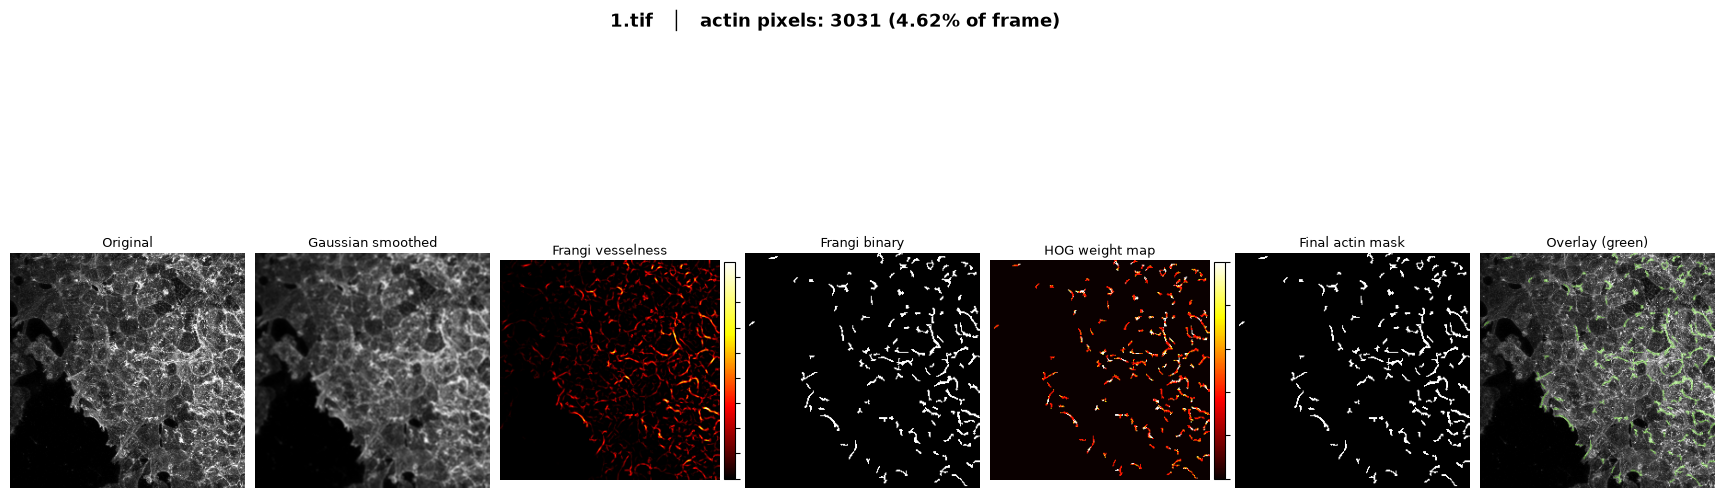

  actin pixels: 3031 / 65536 (4.62%)  │  frangi max: 0.8611  │  mask unique values: [0, 1]



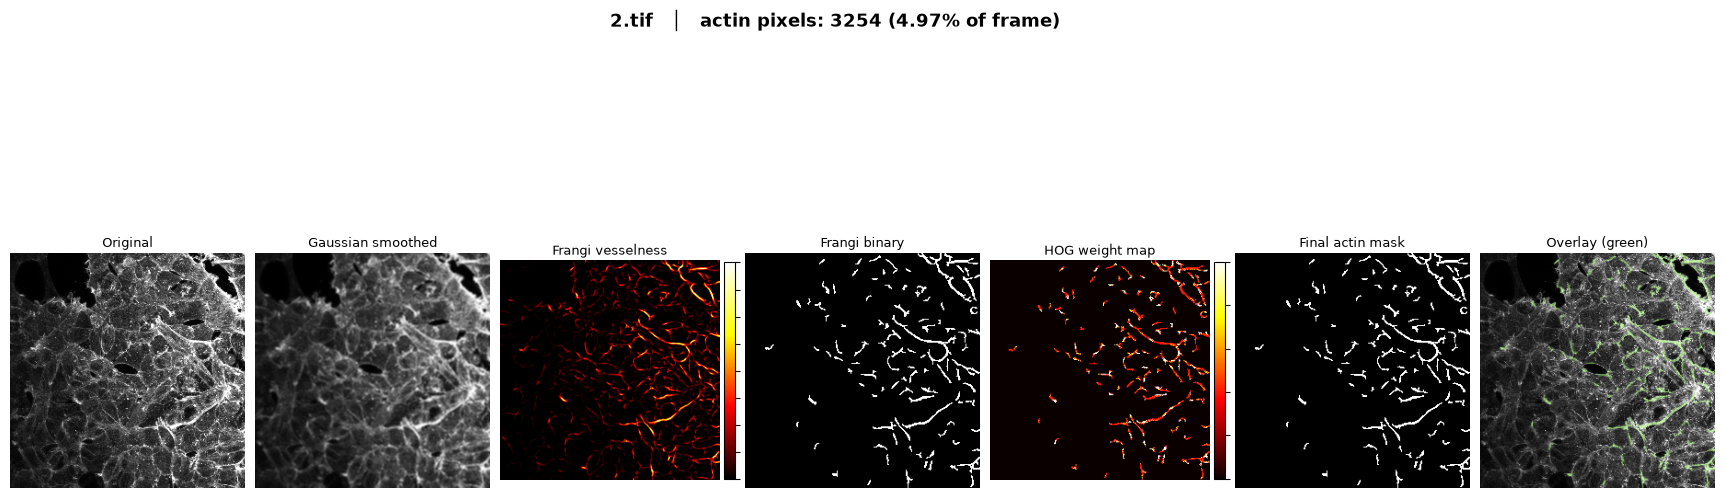

  actin pixels: 3254 / 65536 (4.97%)  │  frangi max: 0.8021  │  mask unique values: [0, 1]



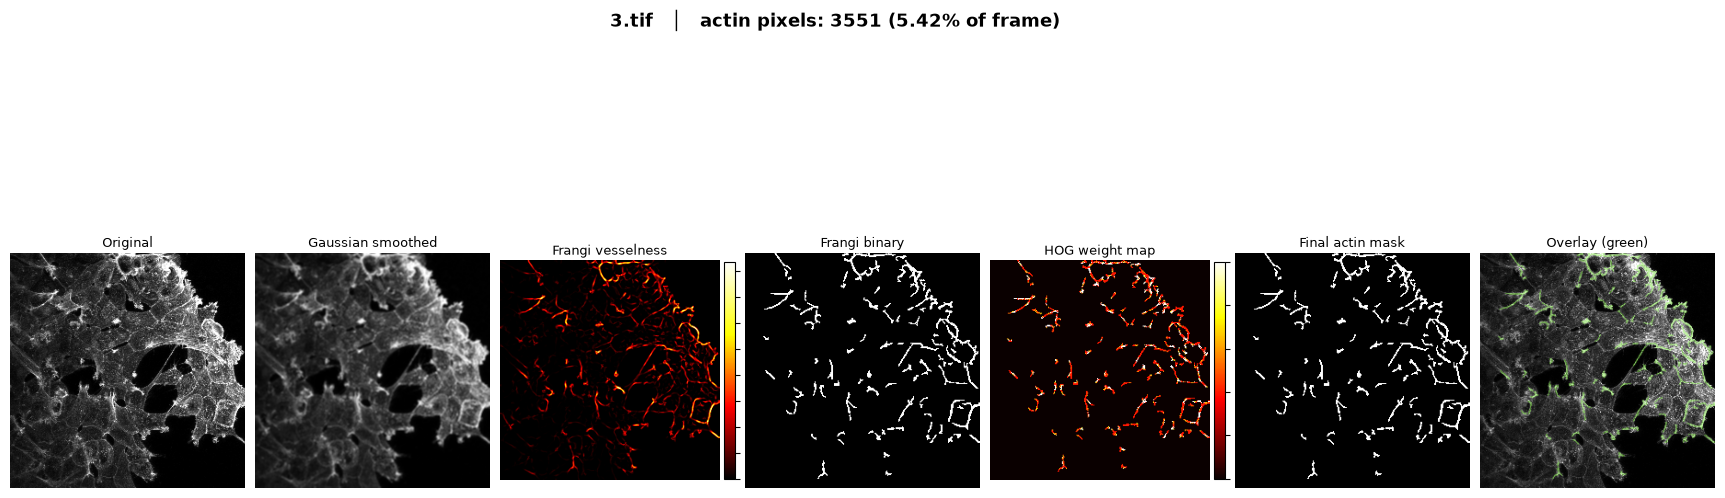

  actin pixels: 3551 / 65536 (5.42%)  │  frangi max: 0.8336  │  mask unique values: [0, 1]



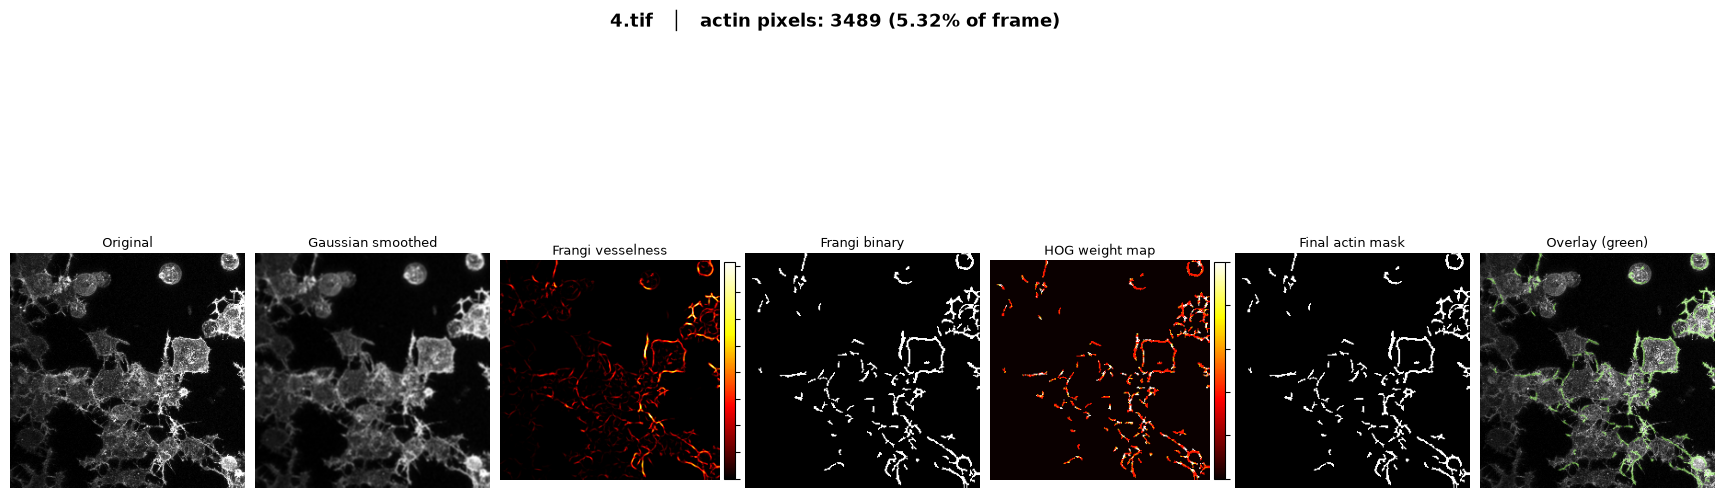

  actin pixels: 3489 / 65536 (5.32%)  │  frangi max: 0.8142  │  mask unique values: [0, 1]



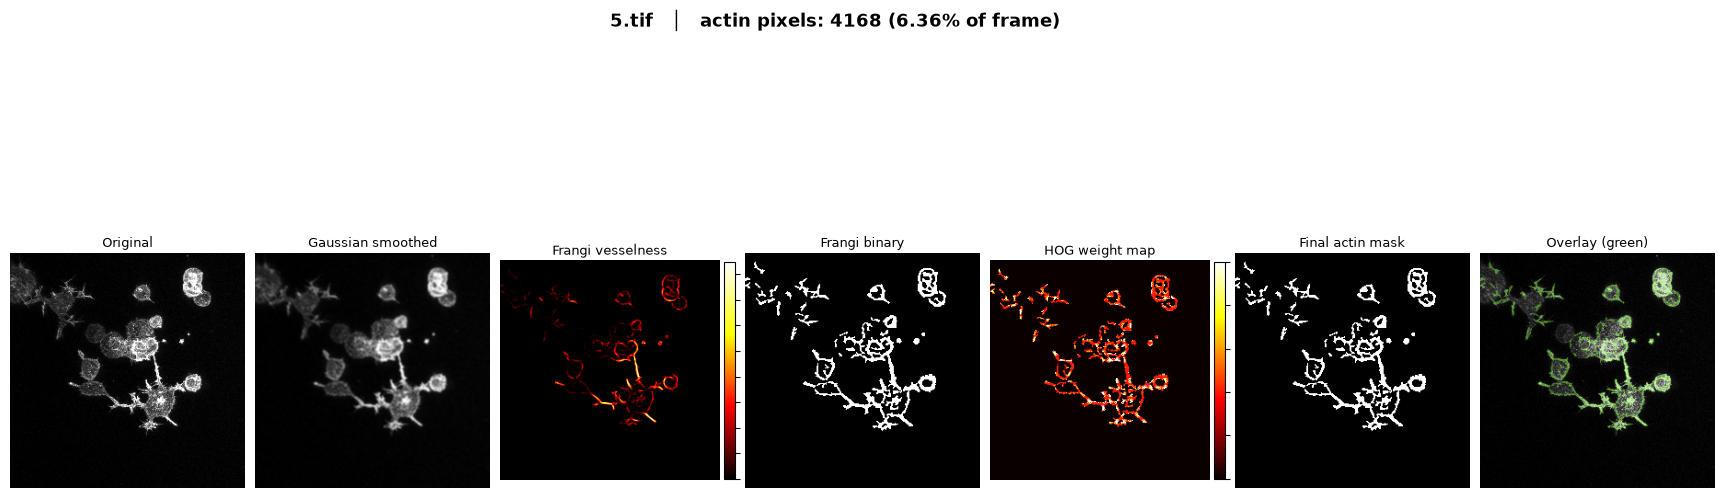

  actin pixels: 4168 / 65536 (6.36%)  │  frangi max: 0.8492  │  mask unique values: [0, 1]



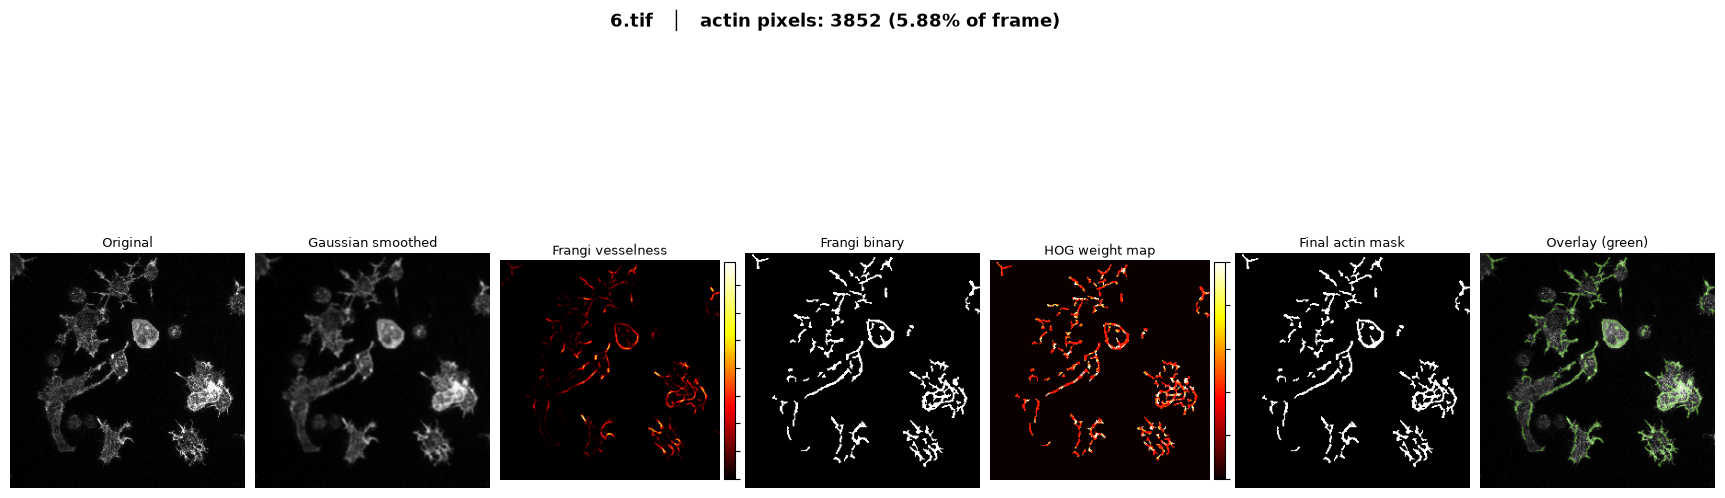

  actin pixels: 3852 / 65536 (5.88%)  │  frangi max: 0.7841  │  mask unique values: [0, 1]



In [5]:
# ── Run for EVERY image ────────────────────────────────────────────────────
# Each image gets its own figure row so you can scroll through all of them.

for path in image_paths:
    plot_image_pipeline(path)

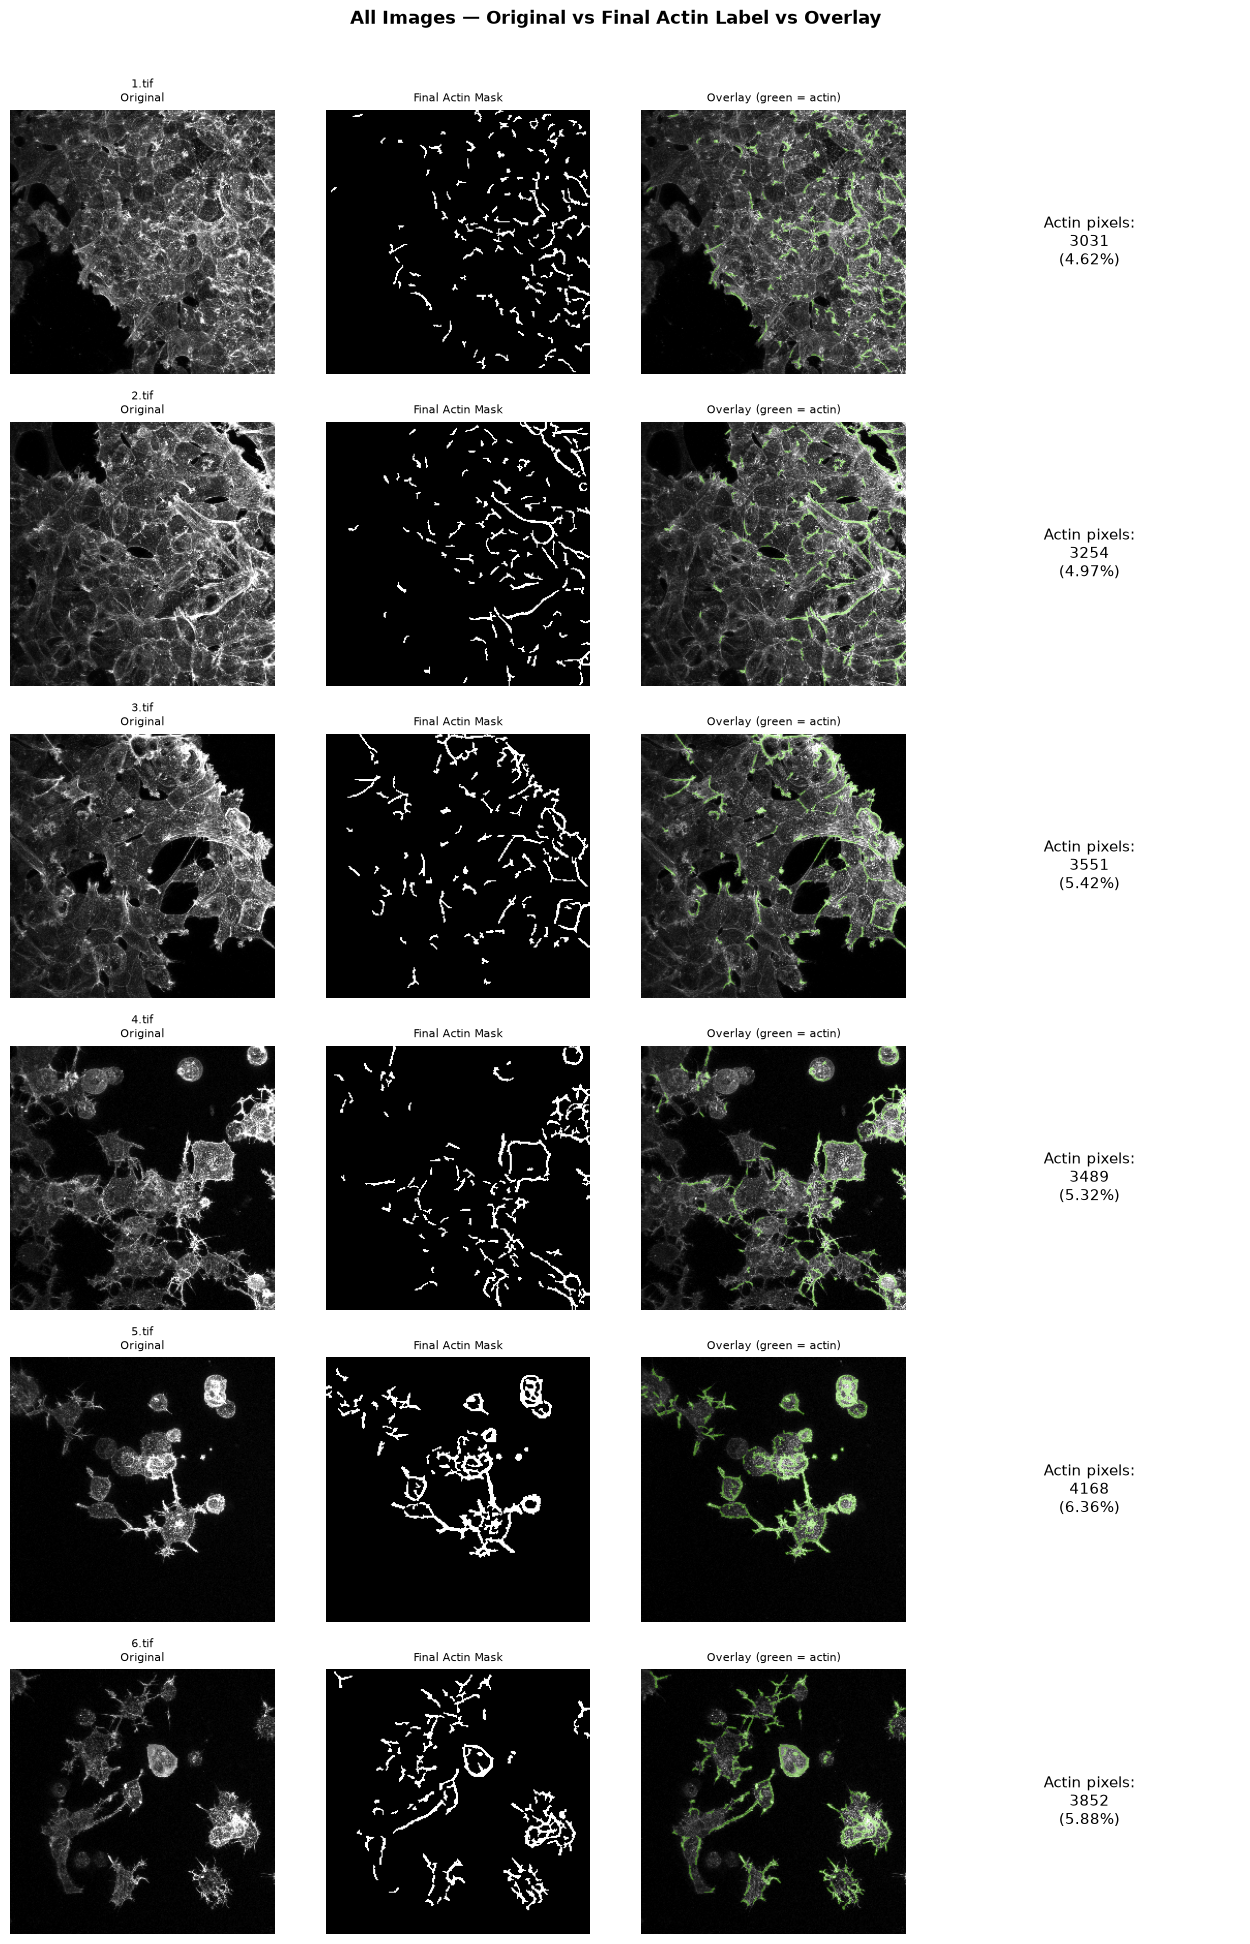

Summary grid saved to: /home/harsh/CV_work/group_8/outputs/label_summary_grid.png


In [6]:
# ── Summary grid: Original vs Final Mask, all images at once ──────────────
# Useful for a single slide showing all 8 images side-by-side.

n = len(image_paths)
cols = 2          # (Original | Mask) per image
rows = n

fig, axes = plt.subplots(rows, cols * 2,
                          figsize=(cols * 2 * 3.2, rows * 3.2))
if rows == 1:
    axes = axes[np.newaxis, :]

for row, path in enumerate(image_paths):
    name   = os.path.basename(path)
    raw    = load_tif_image(path)
    img    = cv2.resize(raw, config.IMAGE_SIZE, interpolation=cv2.INTER_LINEAR)
    result = preprocess_image(img)
    mask   = result['edge_mask']

    # Overlay
    overlay_bgr = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
    green_layer = overlay_bgr.copy()
    green_layer[mask.astype(bool)] = [0, 220, 80]
    overlay_rgb = cv2.cvtColor(
        cv2.addWeighted(overlay_bgr, 0.65, green_layer, 0.35, 0),
        cv2.COLOR_BGR2RGB
    )

    # Column 0-1: original
    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f'{name}\nOriginal', fontsize=8)
    axes[row, 0].axis('off')

    # Column 2-3: final actin mask
    axes[row, 1].imshow(mask, cmap='gray')
    axes[row, 1].set_title('Final Actin Mask', fontsize=8)
    axes[row, 1].axis('off')

    # Column 4-5: overlay
    axes[row, 2].imshow(overlay_rgb)
    axes[row, 2].set_title('Overlay (green = actin)', fontsize=8)
    axes[row, 2].axis('off')

    pct = mask.sum() / (config.IMAGE_SIZE[0] * config.IMAGE_SIZE[1]) * 100
    axes[row, 3].text(0.5, 0.5,
        f'Actin pixels:\n{int(mask.sum())}\n({pct:.2f}%)',
        ha='center', va='center', fontsize=11,
        transform=axes[row, 3].transAxes)
    axes[row, 3].axis('off')

fig.suptitle('All Images — Original vs Final Actin Label vs Overlay',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(config.OUTPUT_DIR, 'label_summary_grid.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Summary grid saved to: {config.OUTPUT_DIR}/label_summary_grid.png')

In [7]:
# ── Per-image statistics table ─────────────────────────────────────────────
import pandas as pd

rows_data = []
for path in image_paths:
    raw    = load_tif_image(path)
    img    = cv2.resize(raw, config.IMAGE_SIZE, interpolation=cv2.INTER_LINEAR)
    result = preprocess_image(img)
    mask   = result['edge_mask']
    fm     = result['frangi_map']

    rows_data.append({
        'image':           os.path.basename(path),
        'actin_pixels':    int(mask.sum()),
        'actin_%':         round(mask.sum() / mask.size * 100, 3),
        'frangi_max':      round(float(fm.max()), 5),
        'frangi_mean_nz':  round(float(fm[fm>0].mean()) if (fm>0).any() else 0, 5),
    })

df = pd.DataFrame(rows_data)
print(df.to_string(index=False))

image  actin_pixels  actin_%  frangi_max  frangi_mean_nz
1.tif          3031    4.625     0.86112         0.03250
2.tif          3254    4.965     0.80213         0.03443
3.tif          3551    5.418     0.83364         0.03124
4.tif          3489    5.324     0.81417         0.02432
5.tif          4168    6.360     0.84918         0.01245
6.tif          3852    5.878     0.78409         0.01313


---
## How to interpret the results

**Good labeling looks like:**
- Final Actin Mask traces continuous bright lines matching the cell-cell junctions in the Original
- Actin % is typically 2–10% for fluorescence actin junction images (not too sparse, not filling the whole frame)
- Overlay shows green lines running along the bright curvilinear structures in the raw image

**If the mask looks wrong**, tune these values in `config.py` (no code change needed elsewhere):

| Parameter | Effect |
|---|---|
| `FRANGI_SIGMAS` | Wider range (e.g. `(1,2,3,4,5,6,7)`) captures thicker actin bundles |
| `FRANGI_THRESHOLD_PERCENTILE` | Lower (e.g. 90) → more actin pixels; Higher (e.g. 97) → fewer, stricter |
| `FRANGI_MIN_COMPONENT_AREA` | Higher (e.g. 20) removes more isolated speckle noise |
| `USE_HOG_REFINEMENT` | Set `False` to see raw Frangi output without HOG filtering |
| `HOG_REFINEMENT_THRESHOLD` | Lower (e.g. 0.2) keeps more HOG-uncertain pixels |

Re-run this notebook after any config change to see the effect instantly.